Train Graph: 123 nodes, 716 edges
Test Graph: 58 nodes, 251 edges


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
<ipython-input-26-4dceb1f75fe9>:105: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


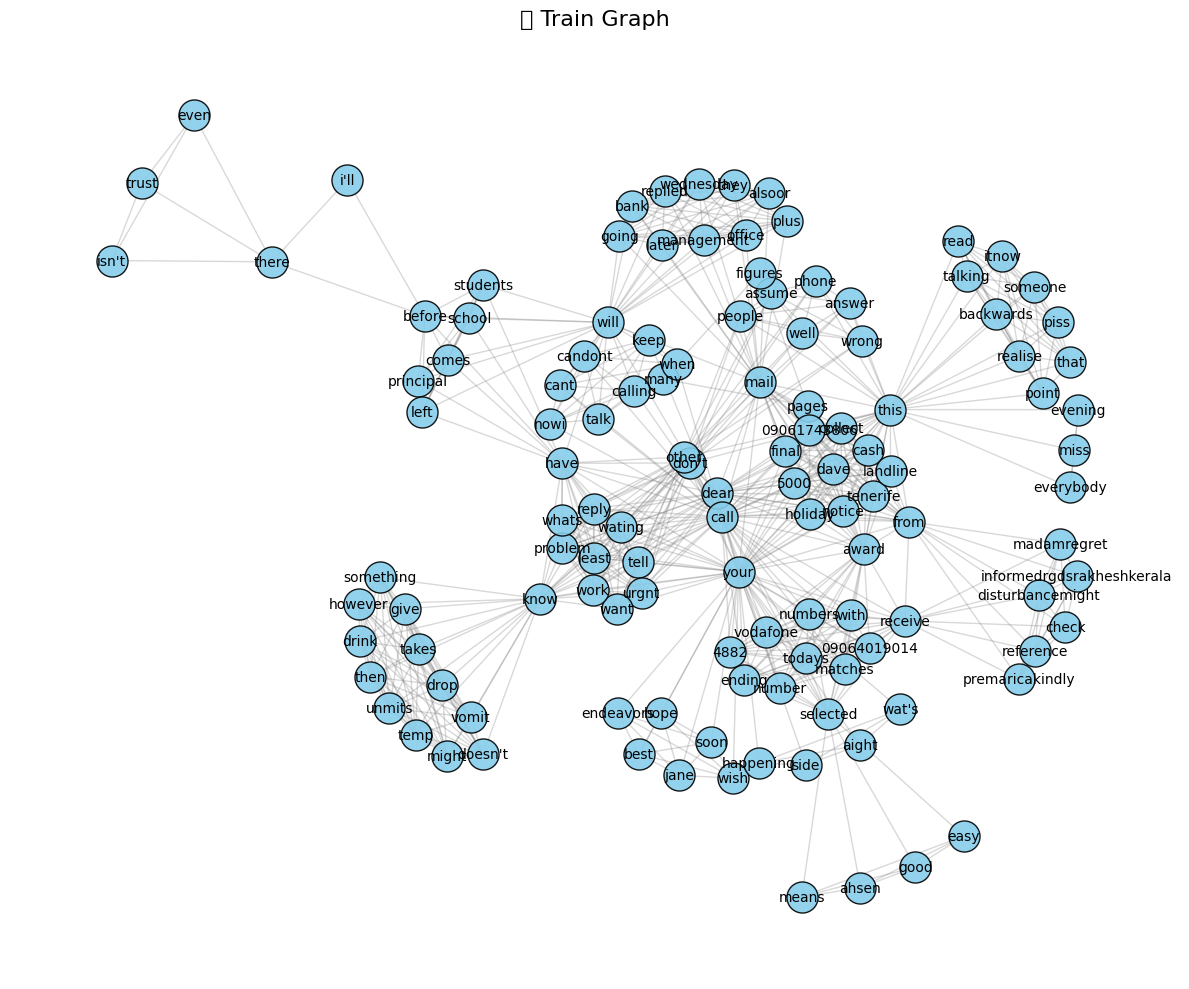

<ipython-input-26-4dceb1f75fe9>:105: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


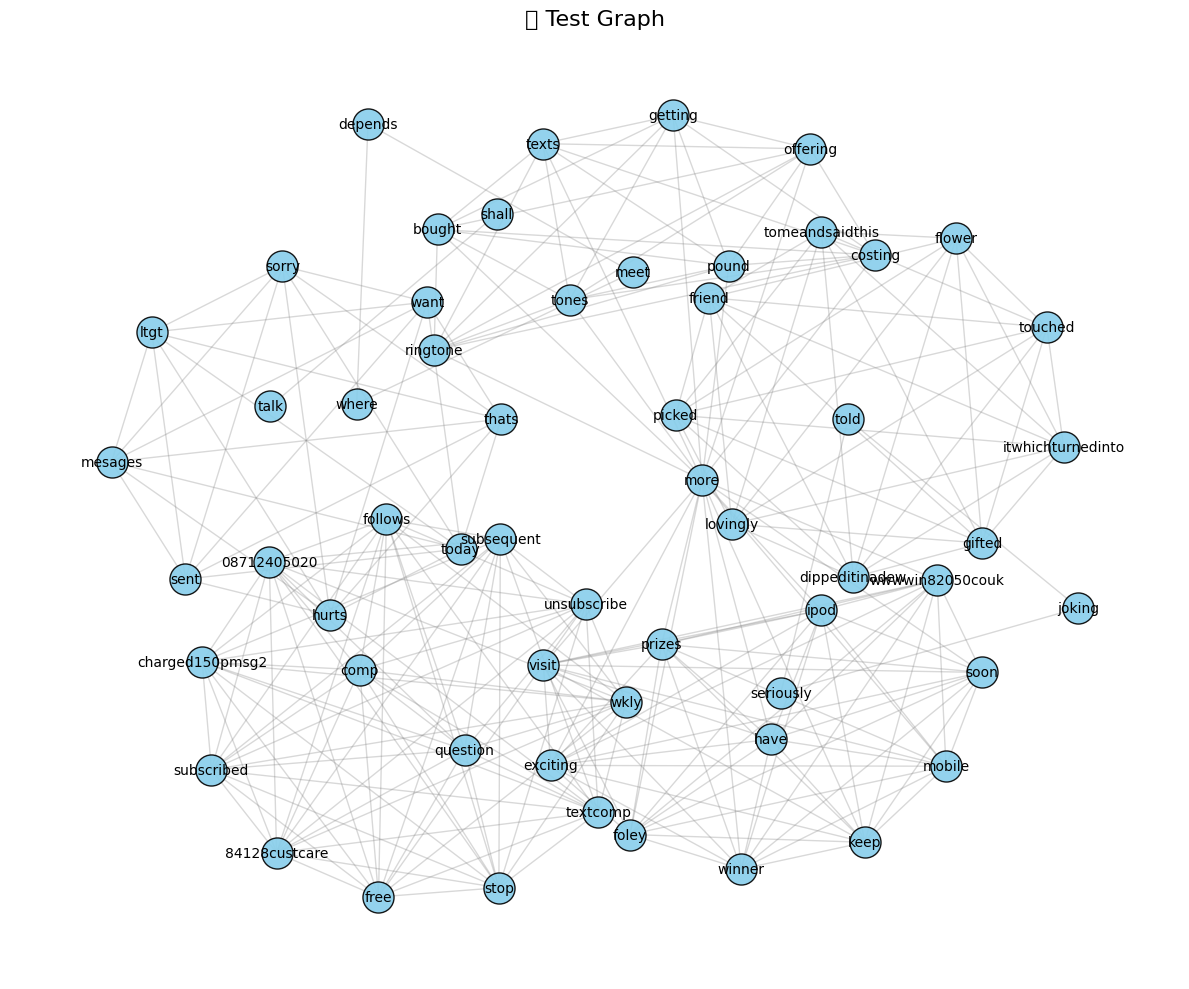

<ipython-input-26-4dceb1f75fe9>:105: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


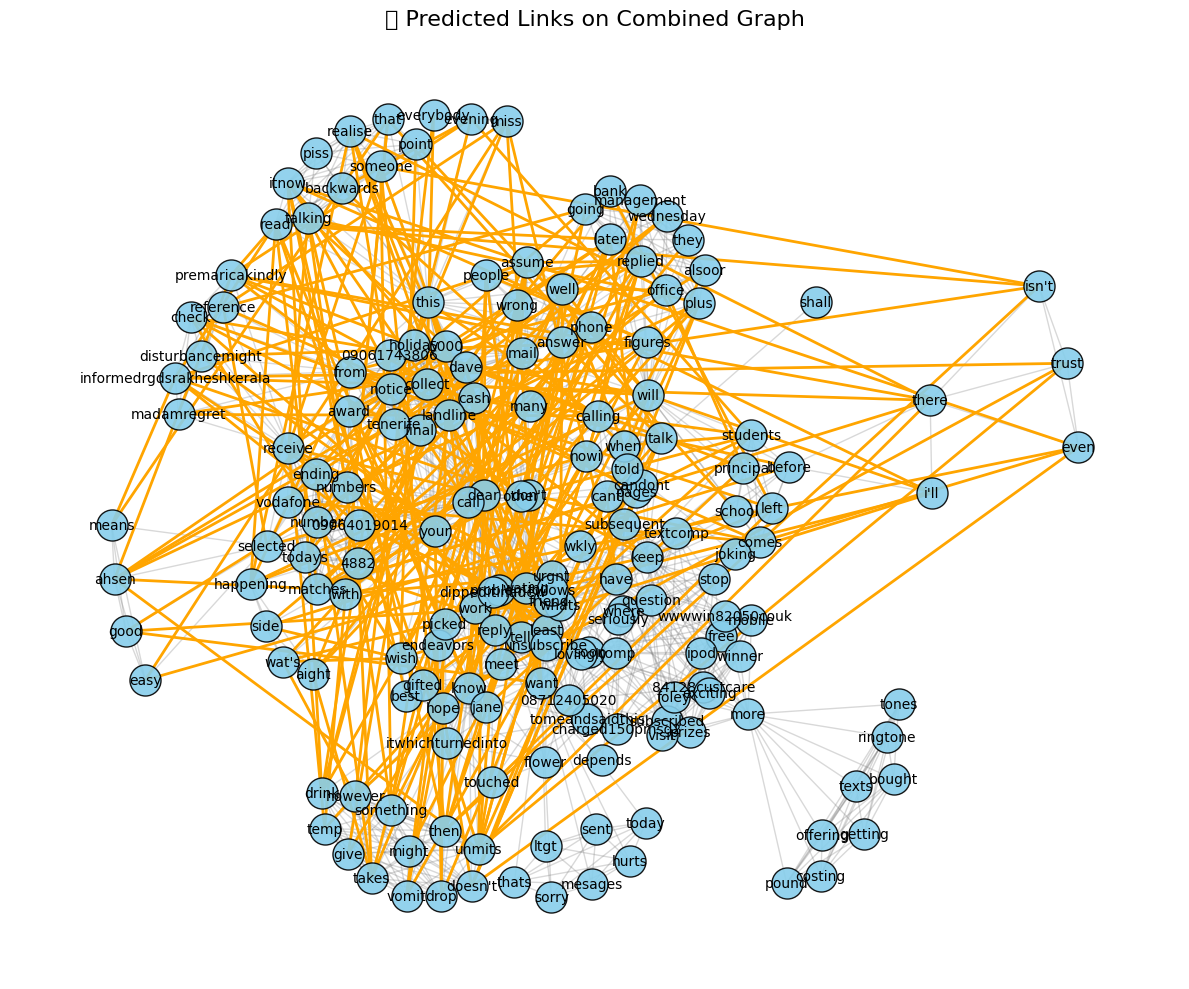

<ipython-input-26-4dceb1f75fe9>:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


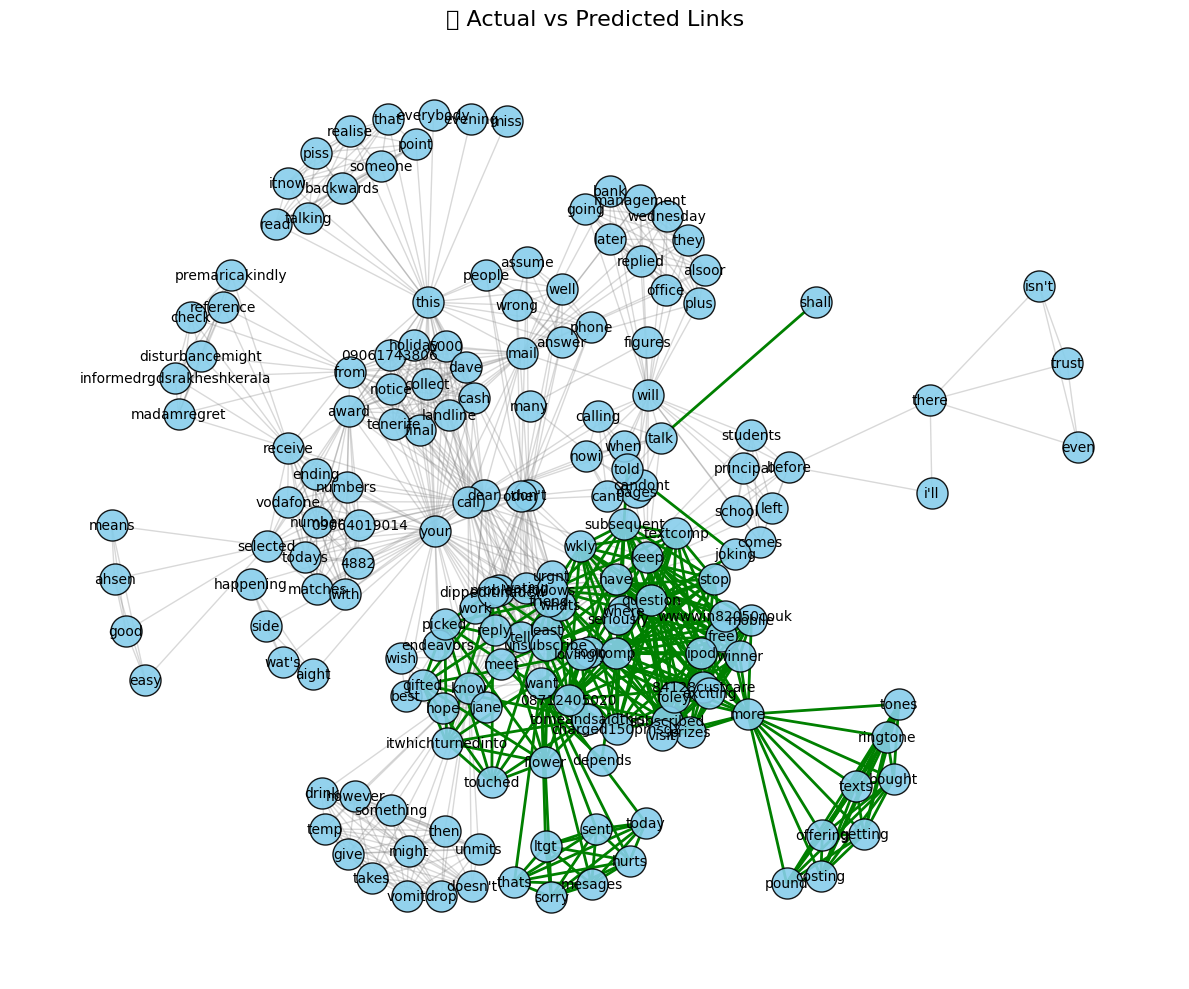

In [26]:
import pandas as pd
import networkx as nx
from sklearn.metrics import precision_score, recall_score
from itertools import combinations
import matplotlib.pyplot as plt
import random

# Load and sample data
df = pd.read_csv("final_data_with_apostrophe.csv")
df = df[['label', 'year', 'message']].dropna()
df['message'] = df['message'].astype(str)

# Take a random sample of 20 rows
df = df.sample(25, random_state=42)

# Train-test split from sample
split_index = int(0.7 * len(df))  # 70% train, 30% test
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Tokenizer (ignore words with length ≤ 3)
def tokenize(msg):
    return [w.lower() for w in msg.split(',') if len(w) > 3]

# Build co-occurrence graph
def build_graph(dataframe):
    G = nx.Graph()
    for _, row in dataframe.iterrows():
        words = list(set(tokenize(row['message'])))
        for u, v in combinations(words, 2):
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)
    return G

# Train/test graphs
G_train = build_graph(train_df)
G_test = build_graph(test_df)

print(f"Train Graph: {G_train.number_of_nodes()} nodes, {G_train.number_of_edges()} edges")
print(f"Test Graph: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")

# -----------------------------
# 🧠 Link Prediction (Common Neighbors)
# -----------------------------
cn_pred = nx.common_neighbor_centrality(G_train)
predicted_scores = sorted(cn_pred, key=lambda x: x[2], reverse=True)

# Convert test graph edges to set
test_edges = set(G_test.edges())
predicted_edges = set((u, v) for u, v, _ in predicted_scores)

# Top-k prediction
top_k = min(len(test_edges), len(predicted_edges))
predicted_topk = set(list(predicted_edges)[:top_k])

# Ground truth labels
y_true = []
y_pred = []

for u, v in predicted_topk:
    label = 1 if (u, v) in test_edges or (v, u) in test_edges else 0
    y_true.append(label)
    y_pred.append(1)

# Add negative samples
neg_pool = set(combinations(G_train.nodes(), 2)) - G_train.edges - test_edges
neg_samples = random.sample(list(neg_pool), min(top_k, len(neg_pool)))
for u, v in neg_samples:
    y_true.append(0)
    y_pred.append(1 if (u, v) in predicted_topk or (v, u) in predicted_topk else 0)

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
# print("\n🔍 Link Prediction Evaluation")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")

# -----------------------------
# 🔍 Visualization
# -----------------------------
def plot_graph(G, title, edge_color='gray', highlight_edges=None, highlight_color='red'):
    if G.number_of_nodes() == 0:
        print(f"⚠️ Cannot plot: {title} is empty.")
        return

    # Use Kamada-Kawai layout for better spacing
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(12, 10))

    # Draw base graph
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color=edge_color)
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue', alpha=0.9, linewidths=1, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

    # Draw highlighted edges (if any)
    if highlight_edges:
        nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, edge_color=highlight_color, width=2)

    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Union of graphs for layout
G_union = nx.compose(G_train, G_test)

# Draw graphs
plot_graph(G_train, "🔷 Train Graph")
plot_graph(G_test, "🟢 Test Graph")

# Highlight predicted links
predicted_edges_highlight = list(predicted_topk)
plot_graph(G_union, "🔮 Predicted Links on Combined Graph", highlight_edges=predicted_edges_highlight, highlight_color='orange')

# Highlight actual vs predicted
plot_graph(G_union, "✅ Actual vs Predicted Links", highlight_edges=list(test_edges), highlight_color='green')



🔍 Link Prediction Evaluation
Precision: 0.0030
Recall: 1.0000
Accuracy: 0.4810


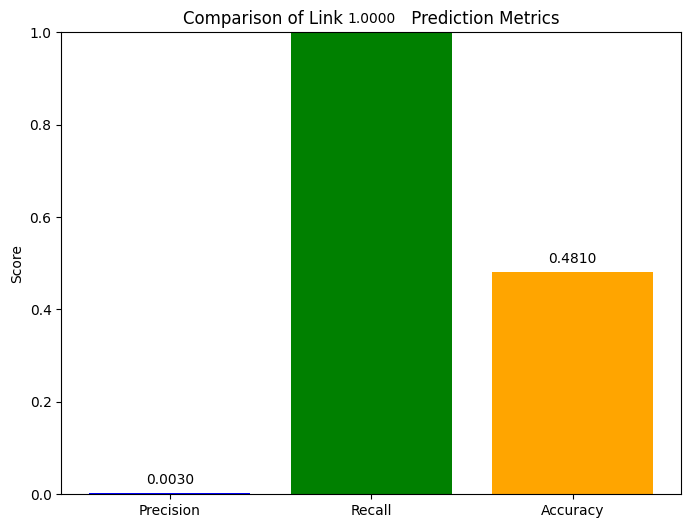

In [25]:
import pandas as pd
import networkx as nx
from sklearn.metrics import precision_score, recall_score, accuracy_score
from itertools import combinations
import matplotlib.pyplot as plt
import random

# Load and sample data
df = pd.read_csv("final_data_with_apostrophe.csv")
df = df[['label', 'year', 'message']].dropna()
df['message'] = df['message'].astype(str)

# Take a random sample of 20 rows
df = df.sample(30, random_state=42)

# Train-test split from sample
split_index = int(0.7 * len(df))  # 70% train, 30% test
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Tokenizer (ignore words with length ≤ 3)
def tokenize(msg):
    return [w.lower() for w in msg.split(',') if len(w) > 3]

# Build co-occurrence graph
def build_graph(dataframe):
    G = nx.Graph()
    for _, row in dataframe.iterrows():
        words = list(set(tokenize(row['message'])))
        label = row['label']  # 1 = fraud, 0 = not fraud
        edge_label = 'fraud' if label == 1 else 'not fraud'

        for u, v in combinations(words, 2):
            u, v = sorted([u, v])
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
                # Store the label for the edge (fraud or not fraud)
                G[u][v]['label'] = edge_label
            else:
                G.add_edge(u, v, weight=1, label=edge_label)
    return G

# Train/test graphs
G_train = build_graph(train_df)
G_test = build_graph(test_df)

# -----------------------------
# 🧠 Link Prediction (Common Neighbors)
# -----------------------------
cn_pred = nx.common_neighbor_centrality(G_train)
predicted_scores = sorted(cn_pred, key=lambda x: x[2], reverse=True)

# Convert test graph edges to set
test_edges = set(G_test.edges())
predicted_edges = set((u, v) for u, v, _ in predicted_scores)

# Top-k prediction
top_k = min(len(test_edges), len(predicted_edges))
predicted_topk = set(list(predicted_edges)[:top_k])

# Ground truth labels
y_true = []
y_pred = []

for u, v in predicted_topk:
    label = 1 if (u, v) in test_edges or (v, u) in test_edges else 0
    y_true.append(label)
    y_pred.append(1)

# Add negative samples
neg_pool = set(combinations(G_train.nodes(), 2)) - G_train.edges - test_edges
neg_samples = random.sample(list(neg_pool), min(top_k, len(neg_pool)))
for u, v in neg_samples:
    y_true.append(0)
    y_pred.append(1 if (u, v) in predicted_topk or (v, u) in predicted_topk else 0)

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

# Display the metrics
print("\n🔍 Link Prediction Evaluation")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# -----------------------------
# 🔍 Visualization of Accuracy & Recall Comparison
# -----------------------------
def plot_metrics_comparison(precision, recall, accuracy):
    # Create bar plot for comparison
    labels = ['Precision', 'Recall', 'Accuracy']
    values = [precision, recall, accuracy]

    plt.figure(figsize=(8, 6))
    plt.bar(labels, values, color=['blue', 'green', 'orange'])

    # Adding labels and title
    plt.ylabel('Score')
    plt.title('Comparison of Link             Prediction Metrics')
    plt.ylim(0, 1)  # Scores range from 0 to 1

    # Display the value on top of the bars
    for i, value in enumerate(values):
        plt.text(i, value + 0.02, f'{value:.4f}', ha='center')

    plt.show()

# Plot the comparison chart
plot_metrics_comparison(precision, recall, accuracy)
